# 01_EDA

## DAY 1 - 모델 전략 수립

전체 과제 범위는 `Batch 1 + Batch 2 + Batch 3`에 대해 5개 질문의 EDA를 수행하고,
그 insight를 토대로 모델 설계 전략을 세우는 것이다.

이 노트북은 그중에서도 **Question 2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?** 담당 범위를 정리한다.

이번 버전의 Q2 비교는 batch 내부 상대 사분위(`Q1/Q4`) 대신,
고정 cutoff 기준 `short-life (cycle_life <= 500) / others (501-999) / long-life (>= 1000)`를 사용한다.

Question 2에서 직접 확인할 포인트:

- 사이클 별 `Qd` 추이 시각화
- 열화 속도가 일정한가, 아니면 가속되는가?
- 급격한 열화 시작점은 어떻게 정의하는 것이 더 타당한가?

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root containing src/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.multi_batch_eda import run_all_batch_analysis

analysis = run_all_batch_analysis(project_root=PROJECT_ROOT, save_markdown=True)
analysis["batch_mapping"]

,batch_key,batch_label,source_path,filename_used,note
0,batch1,Batch 1,/Users/hyun/workspace/data/data/2017-05-12_bat...,2017-05-12_batchdata_updated_struct_errorcorre...,standard file
1,batch2,Batch 2,/Users/hyun/workspace/data/data/2018-02-20_bat...,2018-02-20_batchdata_updated_struct_errorcorre...,workspace fallback file used because the stand...
2,batch3,Batch 3,/Users/hyun/workspace/data/data/2018-04-12_bat...,2018-04-12_batchdata_updated_struct_errorcorre...,standard file


## 1. 데이터 로딩과 전처리 요약

세 배치의 원본 파일 매핑과 filtering 요약을 먼저 확인한다.

참고:
- 현재 워크스페이스에서는 `Batch 2`가 표준 `2017-06-30` 파일이 아니라
  로컬에 존재하는 `2018-02-20` 파일로 매핑될 수 있다.
- 이 경우 아래 표의 `note`에 그대로 표시된다.

In [2]:
display(analysis["batch_mapping"])
display(analysis["preprocess_summary"])

,batch_key,batch_label,source_path,filename_used,note
0,batch1,Batch 1,/Users/hyun/workspace/data/data/2017-05-12_bat...,2017-05-12_batchdata_updated_struct_errorcorre...,standard file
1,batch2,Batch 2,/Users/hyun/workspace/data/data/2018-02-20_bat...,2018-02-20_batchdata_updated_struct_errorcorre...,workspace fallback file used because the stand...
2,batch3,Batch 3,/Users/hyun/workspace/data/data/2018-04-12_bat...,2018-04-12_batchdata_updated_struct_errorcorre...,standard file


,batch_key,batch_label,filename_used,note,cells_used,raw_rows,filtered_rows,removed_rows,removed_ratio_pct,nominal_qd,lower_bound,upper_bound,cycle_life_min,cycle_life_median,cycle_life_max
0,batch1,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...,standard file,46,38811,38763,48,0.1237,1.0796,0.8637,1.2956,534.0,870.0,1227.0
1,batch2,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...,workspace fallback file used because the stand...,47,26904,25980,924,3.4344,1.0943,0.8754,1.3131,392.0,491.0,1186.0
2,batch3,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...,standard file,46,51007,51007,0,0.0000,1.0665,0.8532,1.2799,541.0,1048.0,1935.0


## 2. 각 Batch 내부 비교 그룹

이번 Q2는 batch 내부 상대 순위가 아니라 절대 수명 cutoff로 그룹을 나눈다.

- `cycle_life <= 500`: `short-life`
- `501 <= cycle_life <= 999`: `others`
- `cycle_life >= 1000`: `long-life`

일부 batch에서는 특정 그룹 표본이 비어 있거나 매우 적을 수 있으므로,
그룹 비교는 기술통계적 경향 중심으로 해석한다.

In [3]:
display(analysis["group_summary"])

,batch_key,batch_label,life_group_fixed,count,min,median,max
0,batch1,Batch 1,short-life(<=500),0,NaN,NaN,NaN
1,batch1,Batch 1,others(501-999),36,534.0,772.5,966.0
2,batch1,Batch 1,long-life(>=1000),10,1014.0,1125.5,1227.0
3,batch2,Batch 2,short-life(<=500),28,392.0,449.5,499.0
4,batch2,Batch 2,others(501-999),8,503.0,800.0,997.0
5,batch2,Batch 2,long-life(>=1000),3,1029.0,1140.0,1186.0
6,batch3,Batch 3,short-life(<=500),0,NaN,NaN,NaN
7,batch3,Batch 3,others(501-999),21,541.0,828.0,989.0
8,batch3,Batch 3,long-life(>=1000),23,1002.0,1155.0,1935.0


## 3. Q2-1. 사이클별 Qd 추이

각 batch의 `short-life / others / long-life` 그룹별 `Qd` 중앙값 곡선과
사분위 범위를 비교한다.

핵심은 세 batch 모두 감소 경향을 보이더라도,
감소 시작 시점과 곡선 간격은 batch마다 다르게 나타나는지 확인하는 것이다.

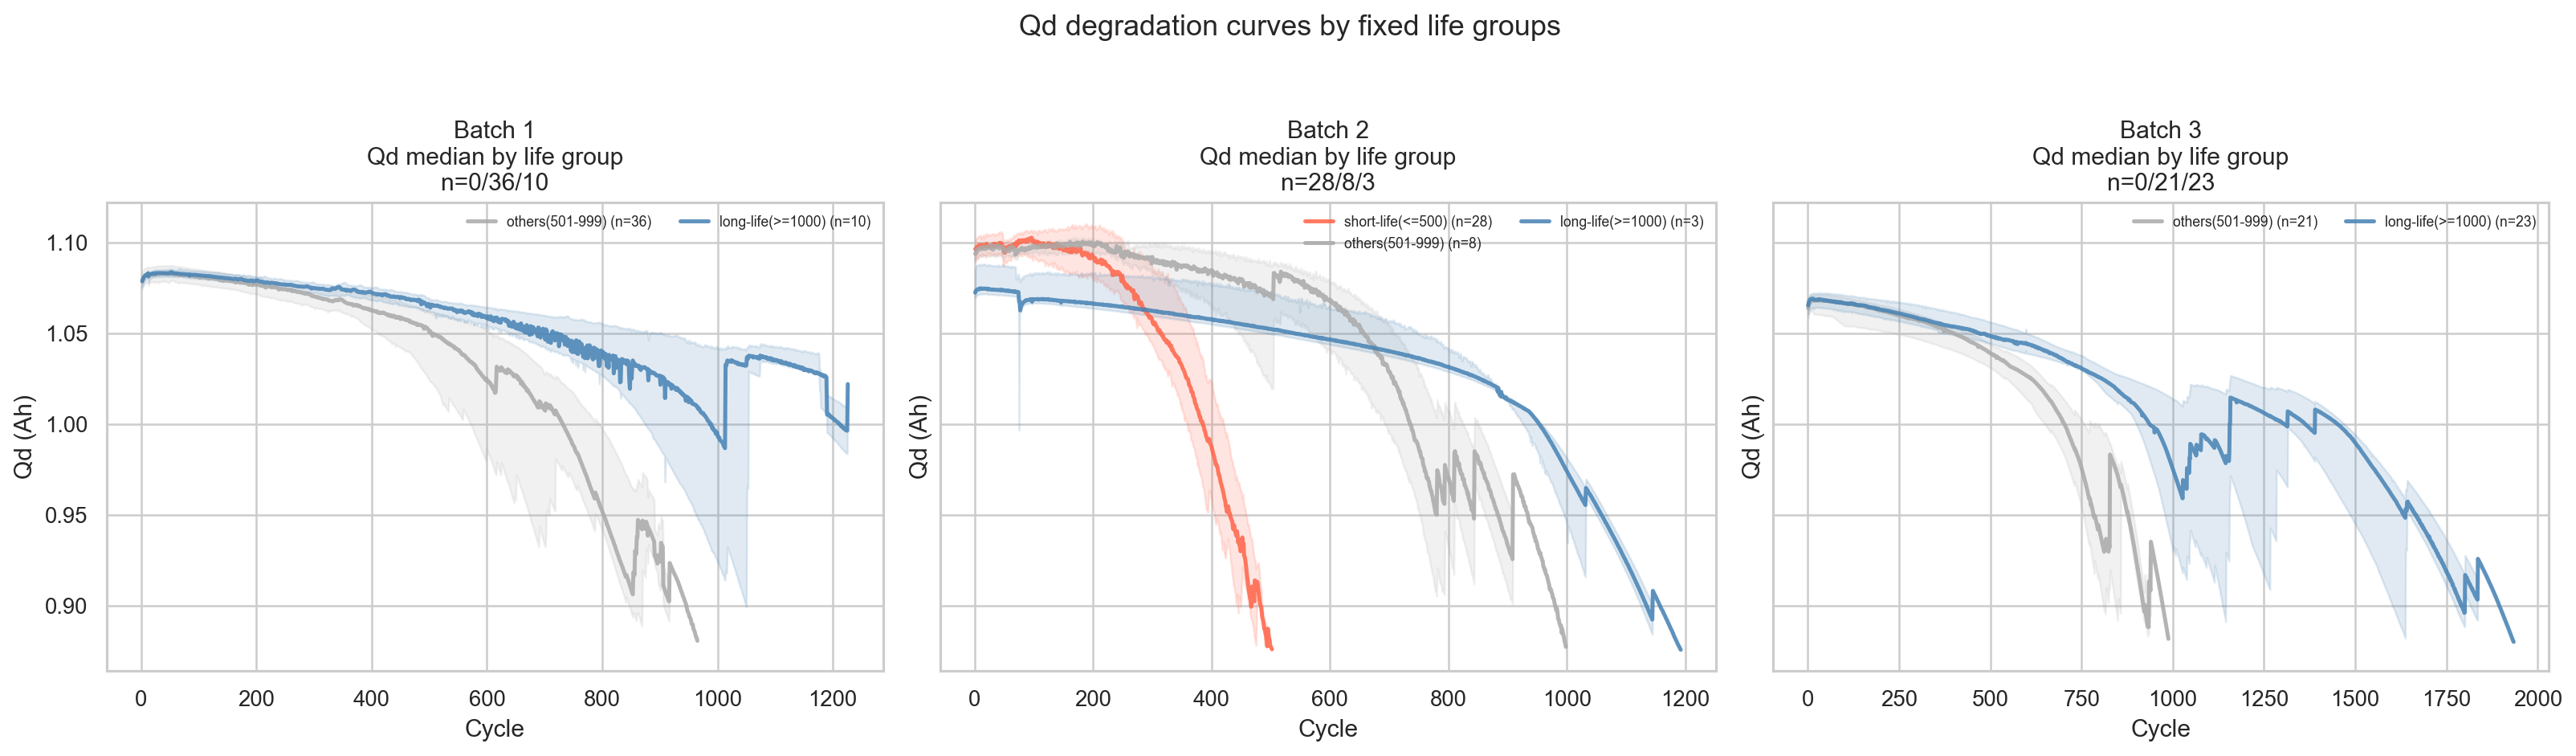

In [4]:
display(Image(filename=str(analysis["figure_paths"]["representative_curves"])))

## 4. Q2-2. 열화 속도는 일정한가, 아니면 가속되는가?

`1-100`, `101-300`, `301+` 구간으로 나누어
retention 기준 `drop per 100 cycles`를 비교한다.

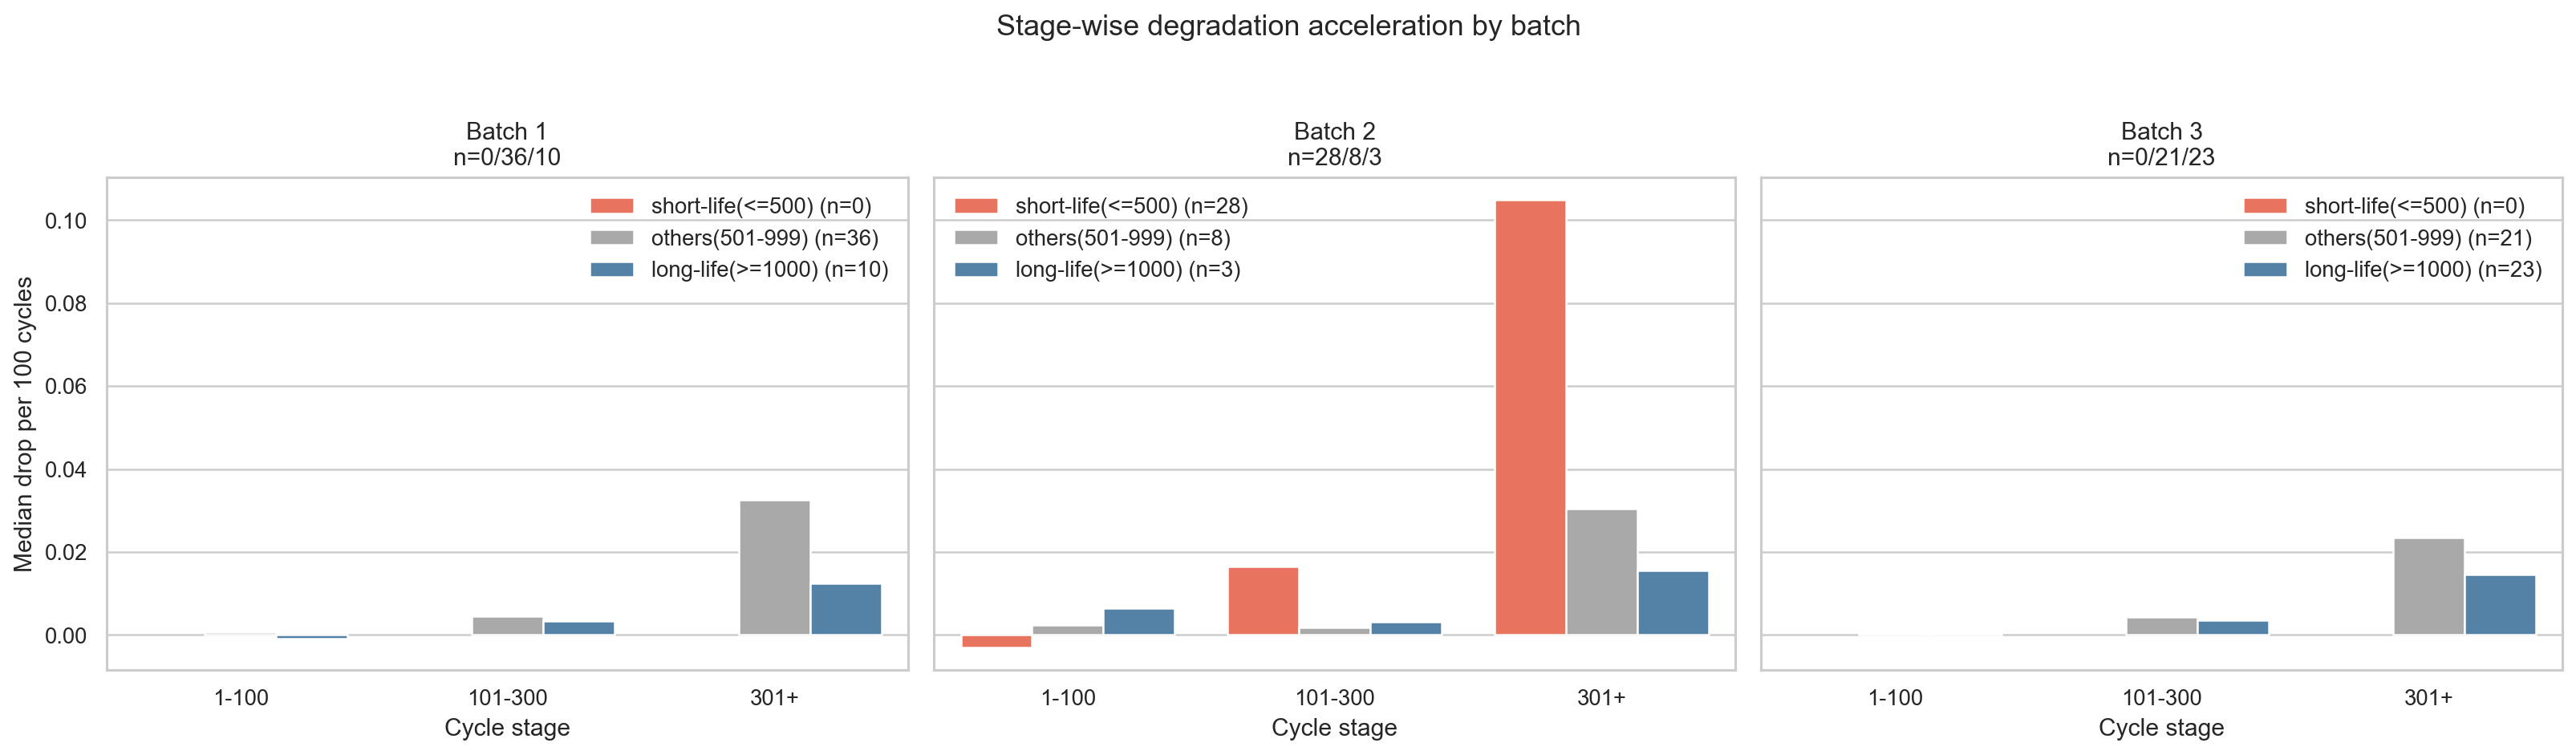

### Batch 1

,batch_key,batch_label,life_group_fixed,stage,drop_per_100_cycles
0,batch1,Batch 1,long-life(>=1000),1-100,-0.000996
1,batch1,Batch 1,long-life(>=1000),101-300,0.003373
2,batch1,Batch 1,long-life(>=1000),301+,0.012534
3,batch1,Batch 1,others(501-999),1-100,0.000644
4,batch1,Batch 1,others(501-999),101-300,0.004572
5,batch1,Batch 1,others(501-999),301+,0.032495


### Batch 2

,batch_key,batch_label,life_group_fixed,stage,drop_per_100_cycles
0,batch2,Batch 2,long-life(>=1000),1-100,0.006354
1,batch2,Batch 2,long-life(>=1000),101-300,0.003084
2,batch2,Batch 2,long-life(>=1000),301+,0.015475
3,batch2,Batch 2,others(501-999),1-100,0.002435
4,batch2,Batch 2,others(501-999),101-300,0.001779
5,batch2,Batch 2,others(501-999),301+,0.030488
6,batch2,Batch 2,short-life(<=500),1-100,-0.003094
7,batch2,Batch 2,short-life(<=500),101-300,0.016476
8,batch2,Batch 2,short-life(<=500),301+,0.104969


### Batch 3

,batch_key,batch_label,life_group_fixed,stage,drop_per_100_cycles
0,batch3,Batch 3,long-life(>=1000),1-100,0.000433
1,batch3,Batch 3,long-life(>=1000),101-300,0.003577
2,batch3,Batch 3,long-life(>=1000),301+,0.014561
3,batch3,Batch 3,others(501-999),1-100,0.000432
4,batch3,Batch 3,others(501-999),101-300,0.004333
5,batch3,Batch 3,others(501-999),301+,0.023391


In [5]:
display(Image(filename=str(analysis["figure_paths"]["stage_comparison"])))
for batch_label, sub in analysis["stage_summary"].groupby("batch_label"):
    display(Markdown(f"### {batch_label}"))
    display(sub.reset_index(drop=True))

## 5. Q2 보강 해석: 고정 기준 그룹별 retention 비교

고정 cutoff 기준 그룹의 retention 곡선과
cycle 50, 100, 300 시점 retention snapshot을 함께 본다.

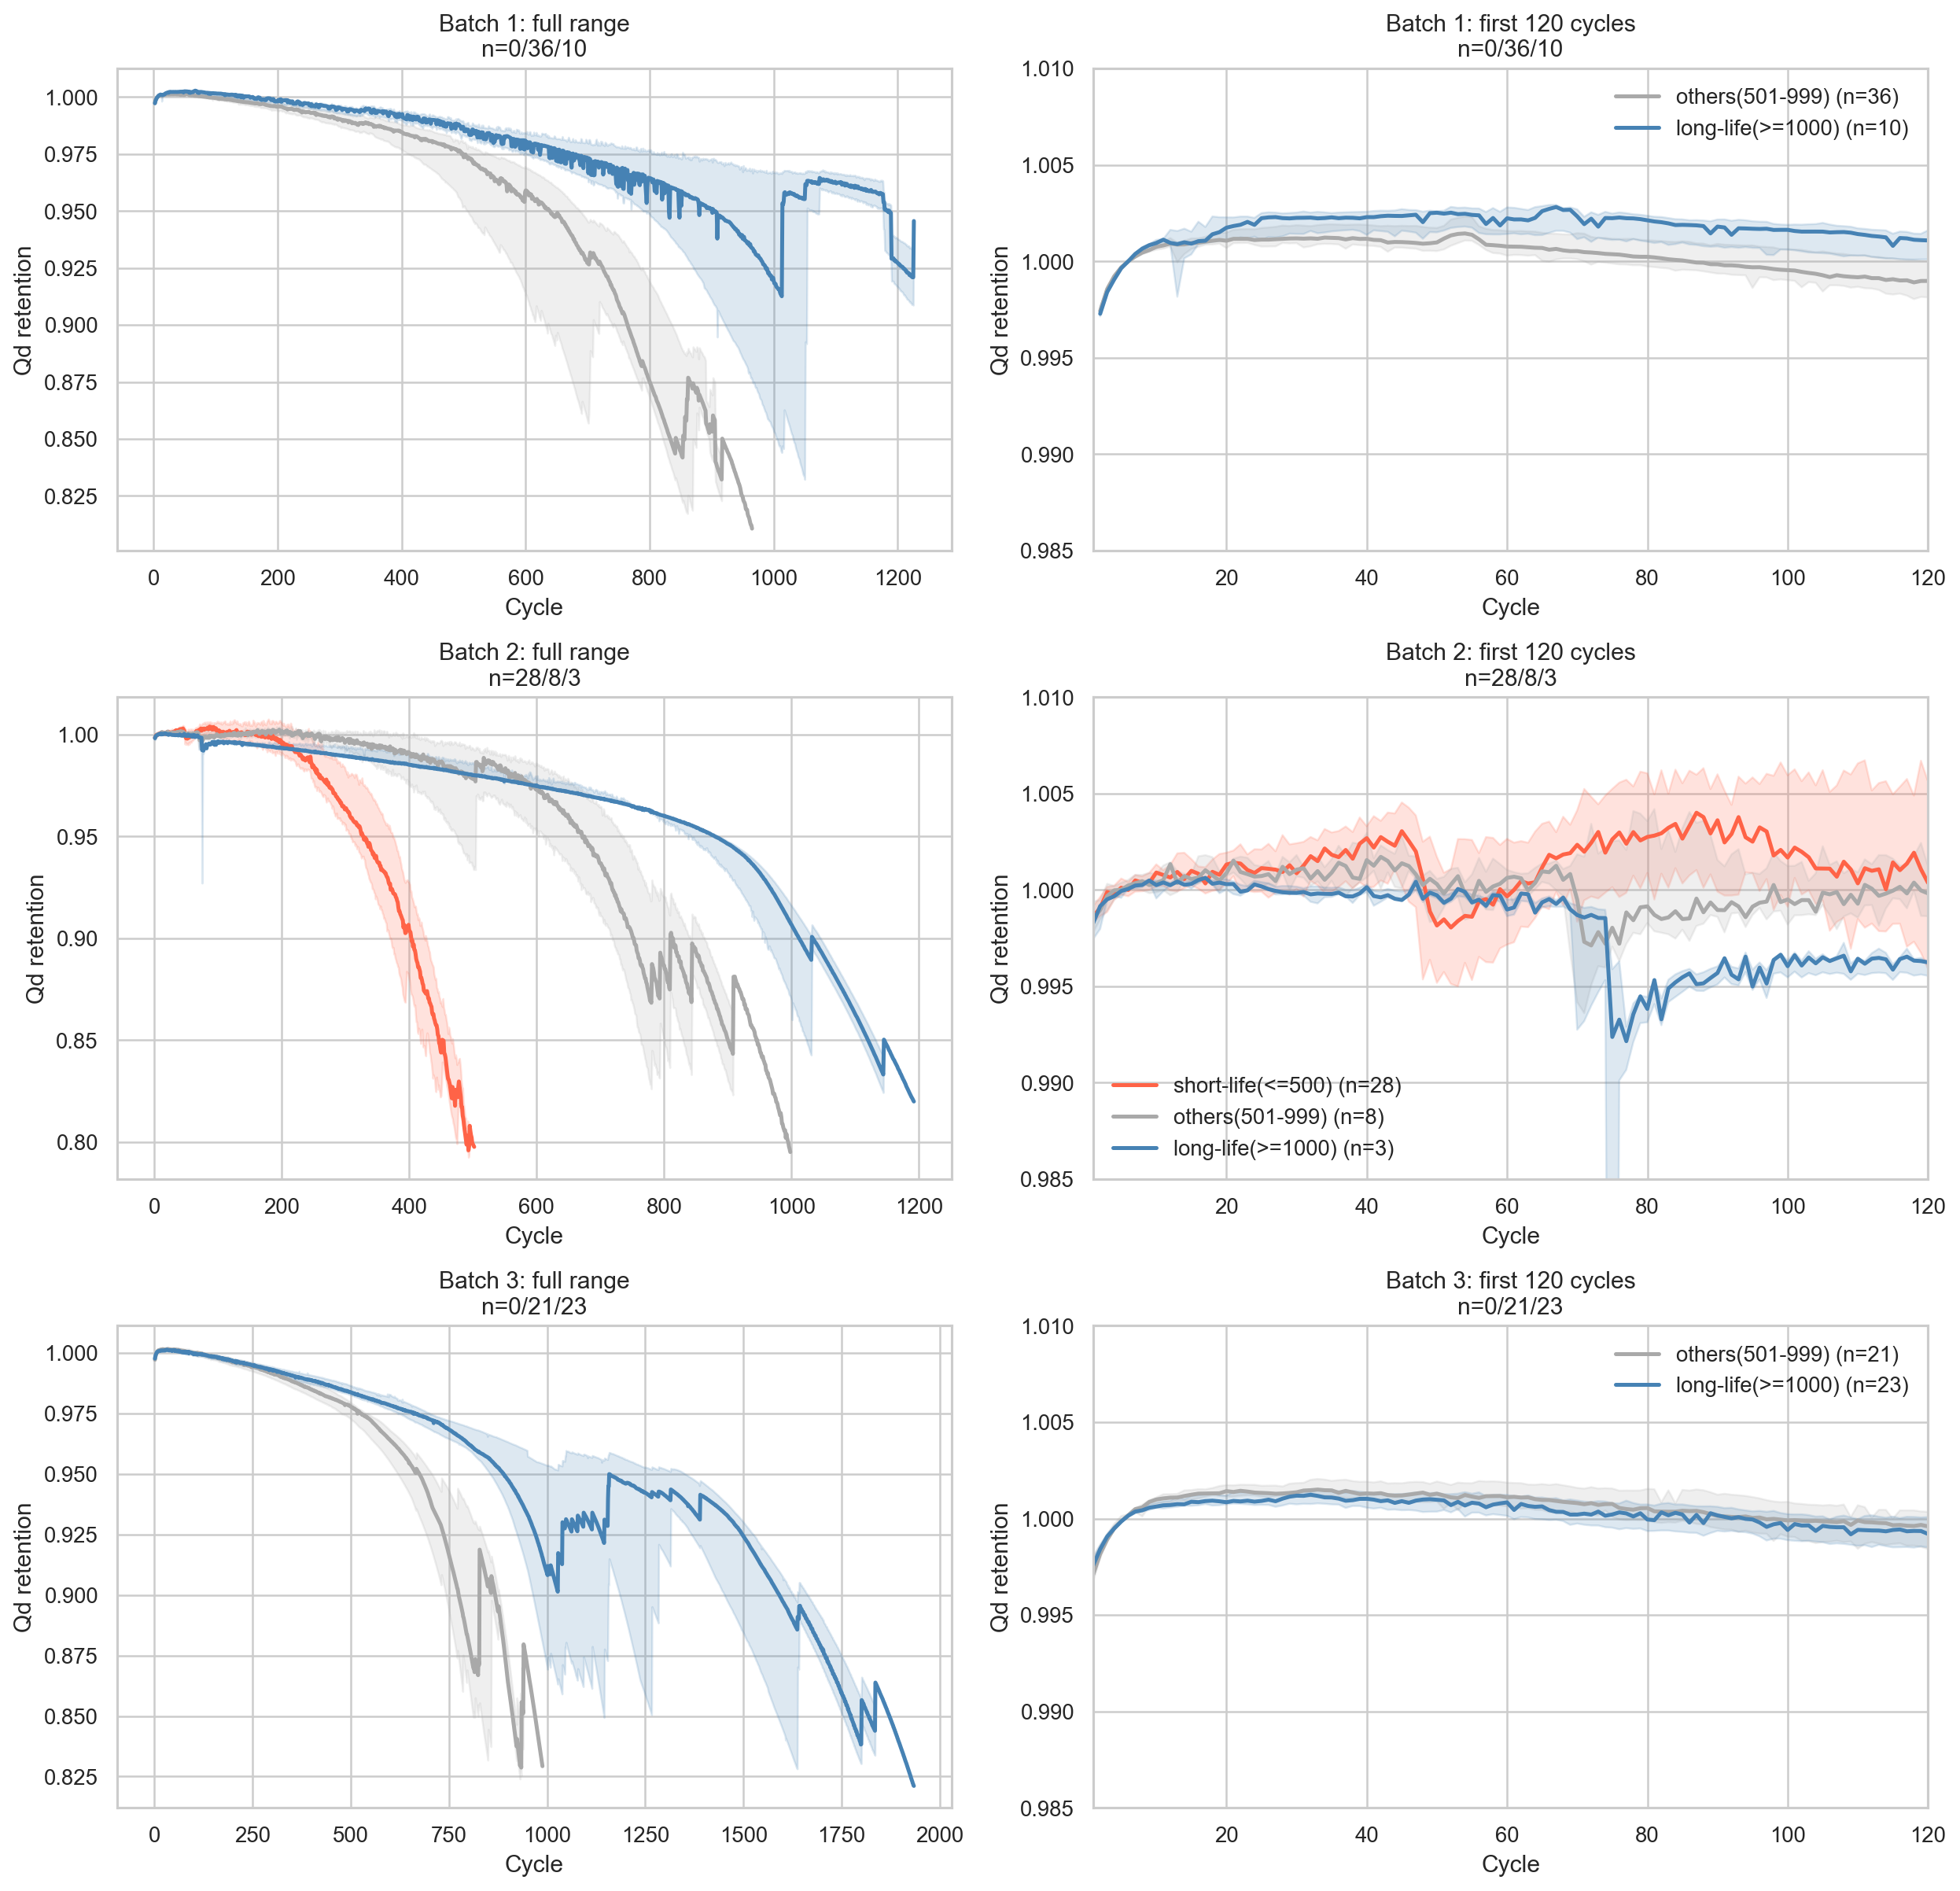

### Batch 1

,batch_key,batch_label,life_group_fixed,cycle,median_retention
0,batch1,Batch 1,others(501-999),50,1.000979
1,batch1,Batch 1,long-life(>=1000),50,1.002521
2,batch1,Batch 1,others(501-999),100,0.999540
3,batch1,Batch 1,long-life(>=1000),100,1.001632
4,batch1,Batch 1,others(501-999),300,0.990311
5,batch1,Batch 1,long-life(>=1000),300,0.995322


### Batch 2

,batch_key,batch_label,life_group_fixed,cycle,median_retention
0,batch2,Batch 2,short-life(<=500),50,0.998156
1,batch2,Batch 2,others(501-999),50,1.000305
2,batch2,Batch 2,long-life(>=1000),50,0.999723
3,batch2,Batch 2,short-life(<=500),100,1.001678
4,batch2,Batch 2,others(501-999),100,0.999506
5,batch2,Batch 2,long-life(>=1000),100,0.996046
6,batch2,Batch 2,short-life(<=500),300,0.963620
7,batch2,Batch 2,others(501-999),300,0.996467
8,batch2,Batch 2,long-life(>=1000),300,0.989410


### Batch 3

,batch_key,batch_label,life_group_fixed,cycle,median_retention
0,batch3,Batch 3,others(501-999),50,1.001291
1,batch3,Batch 3,long-life(>=1000),50,1.000976
2,batch3,Batch 3,others(501-999),100,0.999903
3,batch3,Batch 3,long-life(>=1000),100,0.999411
4,batch3,Batch 3,others(501-999),300,0.991342
5,batch3,Batch 3,long-life(>=1000),300,0.992870


In [6]:
display(Image(filename=str(analysis["figure_paths"]["retention_comparison"])))
for batch_label, sub in analysis["retention_snapshot"].groupby("batch_label"):
    display(Markdown(f"### {batch_label}"))
    display(sub.reset_index(drop=True))

## 6. Q2 보조 해석: knee point는 얼마나 안정적인가?

knee point는 참고할 만한 전환점 후보지만,
이번 데이터에서는 모든 batch와 그룹에서 동일하게 안정적인 핵심 지표는 아니었다.

따라서 여기서는 valid knee 비율과 knee ratio를
보조 근거로만 확인한다.

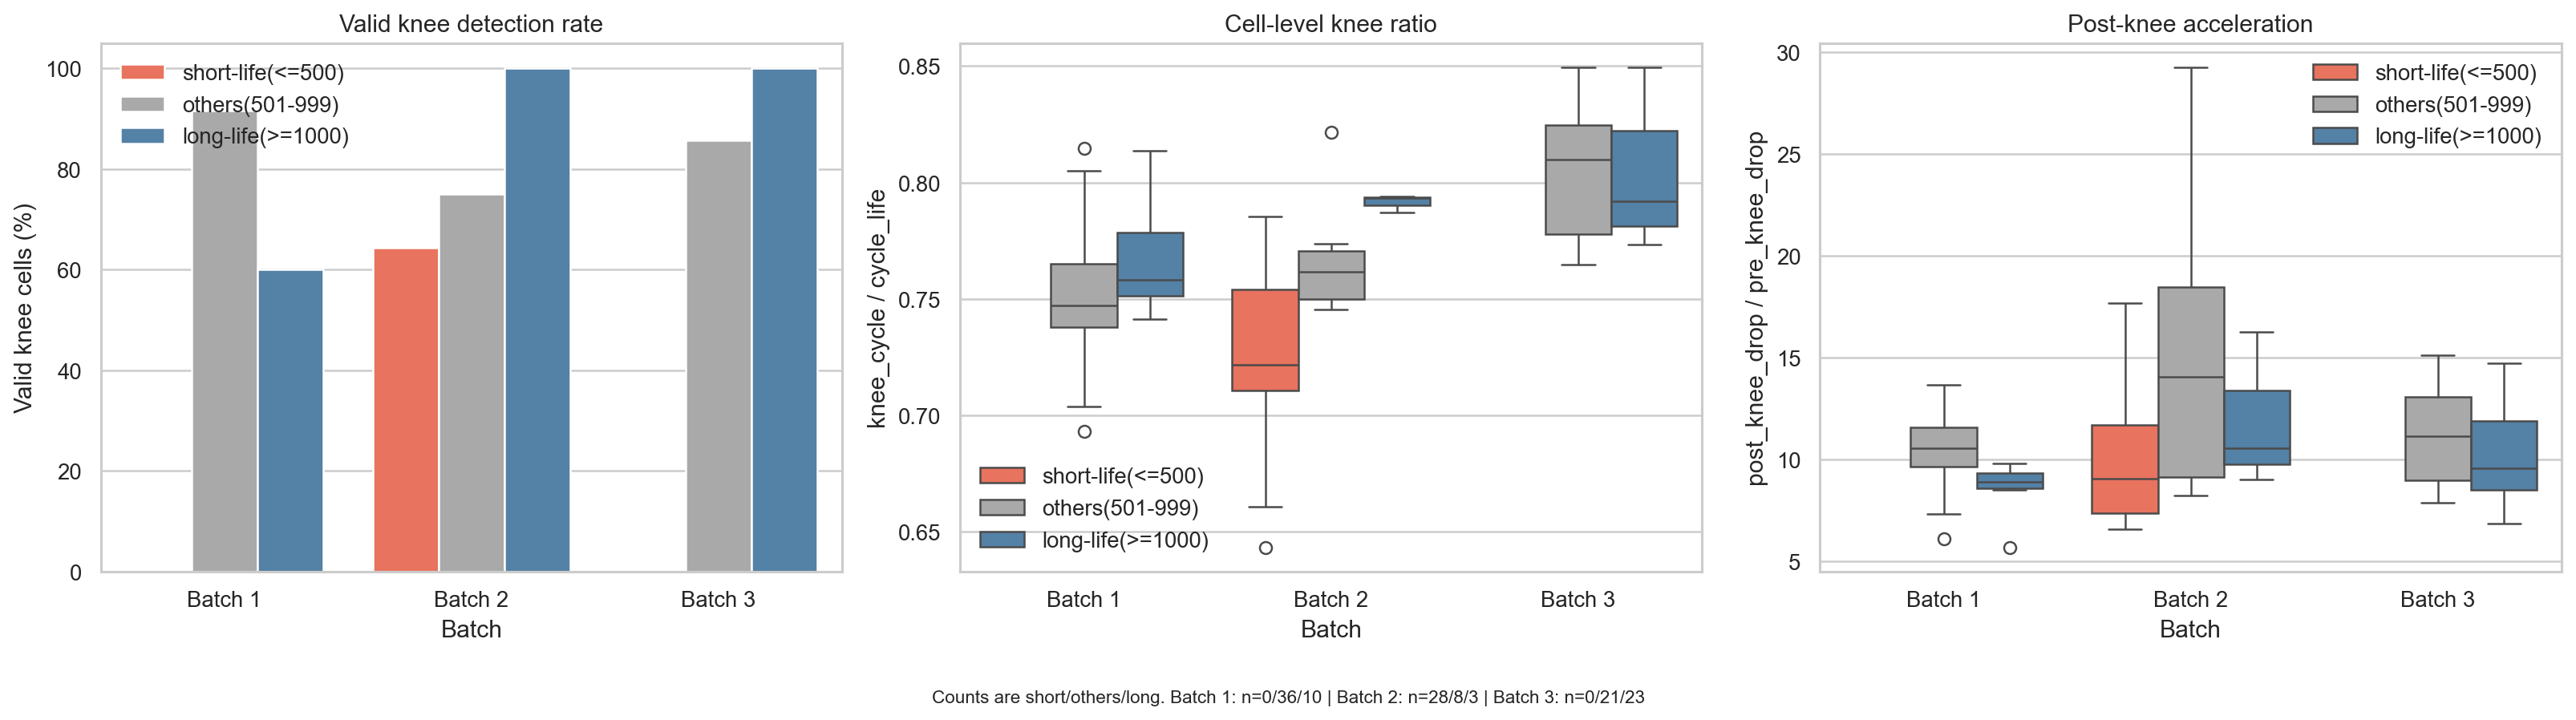

### Batch 1

,batch_key,batch_label,life_group_fixed,n_cells,valid_knee_cells,valid_ratio_pct,knee_cycle_median,knee_ratio_median,retention_at_knee_median,post_pre_slope_ratio_median
0,batch1,Batch 1,long-life(>=1000),10,6,60.000000,794.5,0.758319,0.951066,8.899413
1,batch1,Batch 1,others(501-999),36,33,91.666667,580.0,0.747126,0.957469,10.534160


### Batch 2

,batch_key,batch_label,life_group_fixed,n_cells,valid_knee_cells,valid_ratio_pct,knee_cycle_median,knee_ratio_median,retention_at_knee_median,post_pre_slope_ratio_median
0,batch2,Batch 2,long-life(>=1000),3,3,100.000000,905.0,0.793423,0.945481,10.535025
1,batch2,Batch 2,others(501-999),8,6,75.000000,607.5,0.761668,0.953639,14.022554
2,batch2,Batch 2,short-life(<=500),28,18,64.285714,320.0,0.721718,0.954834,9.043028


### Batch 3

...

,batch_key,batch_label,feature,valid_cells_used,spearman_with_cycle_life
0,batch1,Batch 1,knee_cycle,39,0.981577
1,batch1,Batch 1,knee_ratio,39,0.149104
2,batch1,Batch 1,retention_at_knee,39,-0.212370
3,batch1,Batch 1,post_pre_slope_ratio,39,-0.575868
4,batch1,Batch 1,knee_score,39,-0.599352
5,batch1,Batch 1,pre_knee_drop_per_100,39,-0.764450
6,batch1,Batch 1,post_knee_drop_per_100,39,-0.901508


#### Batch 2 knee correlations

,batch_key,batch_label,feature,valid_cells_used,spearman_with_cycle_life
0,batch2,Batch 2,knee_cycle,27,0.916196
1,batch2,Batch 2,knee_ratio,27,0.572650
2,batch2,Batch 2,knee_score,27,0.457875
3,batch2,Batch 2,post_pre_slope_ratio,27,0.186813
4,batch2,Batch 2,retention_at_knee,27,-0.301587
5,batch2,Batch 2,pre_knee_drop_per_100,27,-0.598291
6,batch2,Batch 2,post_knee_drop_per_100,27,-0.705739


#### Batch 3 knee correlations

,batch_key,batch_label,feature,valid_cells_used,spearman_with_cycle_life
0,batch3,Batch 3,knee_cycle,41,0.976783
1,batch3,Batch 3,knee_score,41,0.593954
2,batch3,Batch 3,knee_ratio,41,0.001045
3,batch3,Batch 3,post_pre_slope_ratio,41,-0.403781
4,batch3,Batch 3,retention_at_knee,41,-0.605279
5,batch3,Batch 3,post_knee_drop_per_100,41,-0.784476
6,batch3,Batch 3,pre_knee_drop_per_100,41,-0.872811


In [7]:
display(Image(filename=str(analysis["figure_paths"]["knee_diagnostics"])))
for batch_label, sub in analysis["knee_group_summary"].groupby("batch_label"):
    display(Markdown(f"### {batch_label}"))
    display(sub.reset_index(drop=True))

for batch_label, sub in analysis["knee_correlations"].sort_values(
    ["batch_label", "spearman_with_cycle_life"], ascending=[True, False]
).groupby("batch_label"):
    display(Markdown(f"#### {batch_label} knee correlations"))
    display(sub.reset_index(drop=True))

## 7. Q2-3. 가속 시작점 해석

이번 데이터에서는 단일 knee point보다 `acceleration onset`이
그룹 차이를 더 안정적으로 설명한다.

함께 보는 보조 지표는 다음과 같다.

- `acceleration onset ratio`
- `cycle_to_99_retention`
- `cycle_to_95_retention`
- `cycle_to_90_retention`

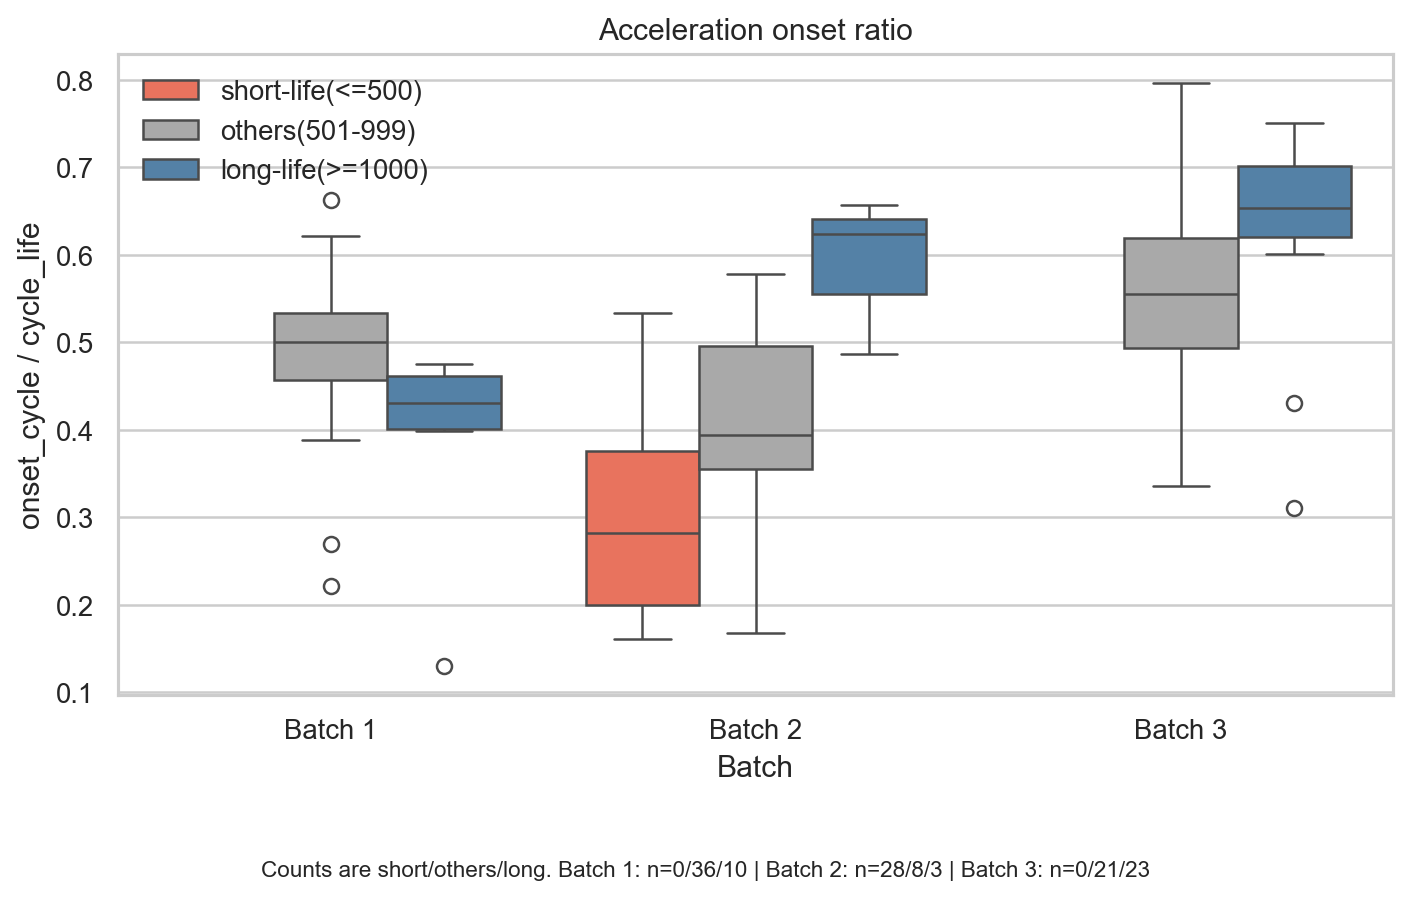

### Batch 1

,batch_key,batch_label,life_group_fixed,n_cells,valid_onset_cells,valid_onset_ratio_pct,accel_onset_cycle_median,accel_onset_ratio_median,cycle_to_99_retention_median,cycle_to_95_retention_median,cycle_to_90_retention_median
0,batch1,Batch 1,long-life(>=1000),10,10,100.0,482.5,0.430036,417.5,800.0,925.0
1,batch1,Batch 1,others(501-999),36,36,100.0,396.0,0.500691,305.5,588.5,669.0


### Batch 2

,batch_key,batch_label,life_group_fixed,n_cells,valid_onset_cells,valid_onset_ratio_pct,accel_onset_cycle_median,accel_onset_ratio_median,cycle_to_99_retention_median,cycle_to_95_retention_median,cycle_to_90_retention_median
0,batch2,Batch 2,long-life(>=1000),3,3,100.0,740.0,0.623946,288.0,881.0,1012.0
1,batch2,Batch 2,others(501-999),8,8,100.0,297.0,0.393666,408.5,617.5,719.5
2,batch2,Batch 2,short-life(<=500),28,28,100.0,118.0,0.281662,227.5,330.0,397.0


### Batch 3

...

,batch_key,batch_label,feature,valid_cells_used,spearman_with_cycle_life
0,batch1,Batch 1,cycle_to_90_retention,42,0.987236
1,batch1,Batch 1,cycle_to_95_retention,43,0.980592
2,batch1,Batch 1,cycle_to_99_retention,46,0.820643
3,batch1,Batch 1,accel_onset_ratio,46,-0.104601


#### Batch 2 transition correlations

,batch_key,batch_label,feature,valid_cells_used,spearman_with_cycle_life
0,batch2,Batch 2,cycle_to_90_retention,39,0.974538
1,batch2,Batch 2,cycle_to_95_retention,39,0.897484
2,batch2,Batch 2,cycle_to_99_retention,39,0.599970
3,batch2,Batch 2,accel_onset_ratio,39,0.498836


#### Batch 3 transition correlations

,batch_key,batch_label,feature,valid_cells_used,spearman_with_cycle_life
0,batch3,Batch 3,cycle_to_90_retention,44,0.995454
1,batch3,Batch 3,cycle_to_95_retention,44,0.979311
2,batch3,Batch 3,cycle_to_99_retention,44,0.510873
3,batch3,Batch 3,accel_onset_ratio,44,0.419480


In [8]:
display(Image(filename=str(analysis["figure_paths"]["transition_diagnostics"])))
for batch_label, sub in analysis["transition_group_summary"].groupby("batch_label"):
    display(Markdown(f"### {batch_label}"))
    display(sub.reset_index(drop=True))

for batch_label, sub in analysis["transition_correlations"][
    analysis["transition_correlations"]["feature"].isin(
        [
            "accel_onset_ratio",
            "cycle_to_99_retention",
            "cycle_to_95_retention",
            "cycle_to_90_retention",
        ]
    )
].sort_values(
    ["batch_label", "spearman_with_cycle_life"], ascending=[True, False]
).groupby("batch_label"):
    display(Markdown(f"#### {batch_label} transition correlations"))
    display(sub.reset_index(drop=True))

## 8. Q2-4. 초기 열화 신호와 모델링 연결

초기 감소량, retention, slope, 그리고 일부 운전/온도 feature를 포함해
batch별 상관 신호를 비교한다.

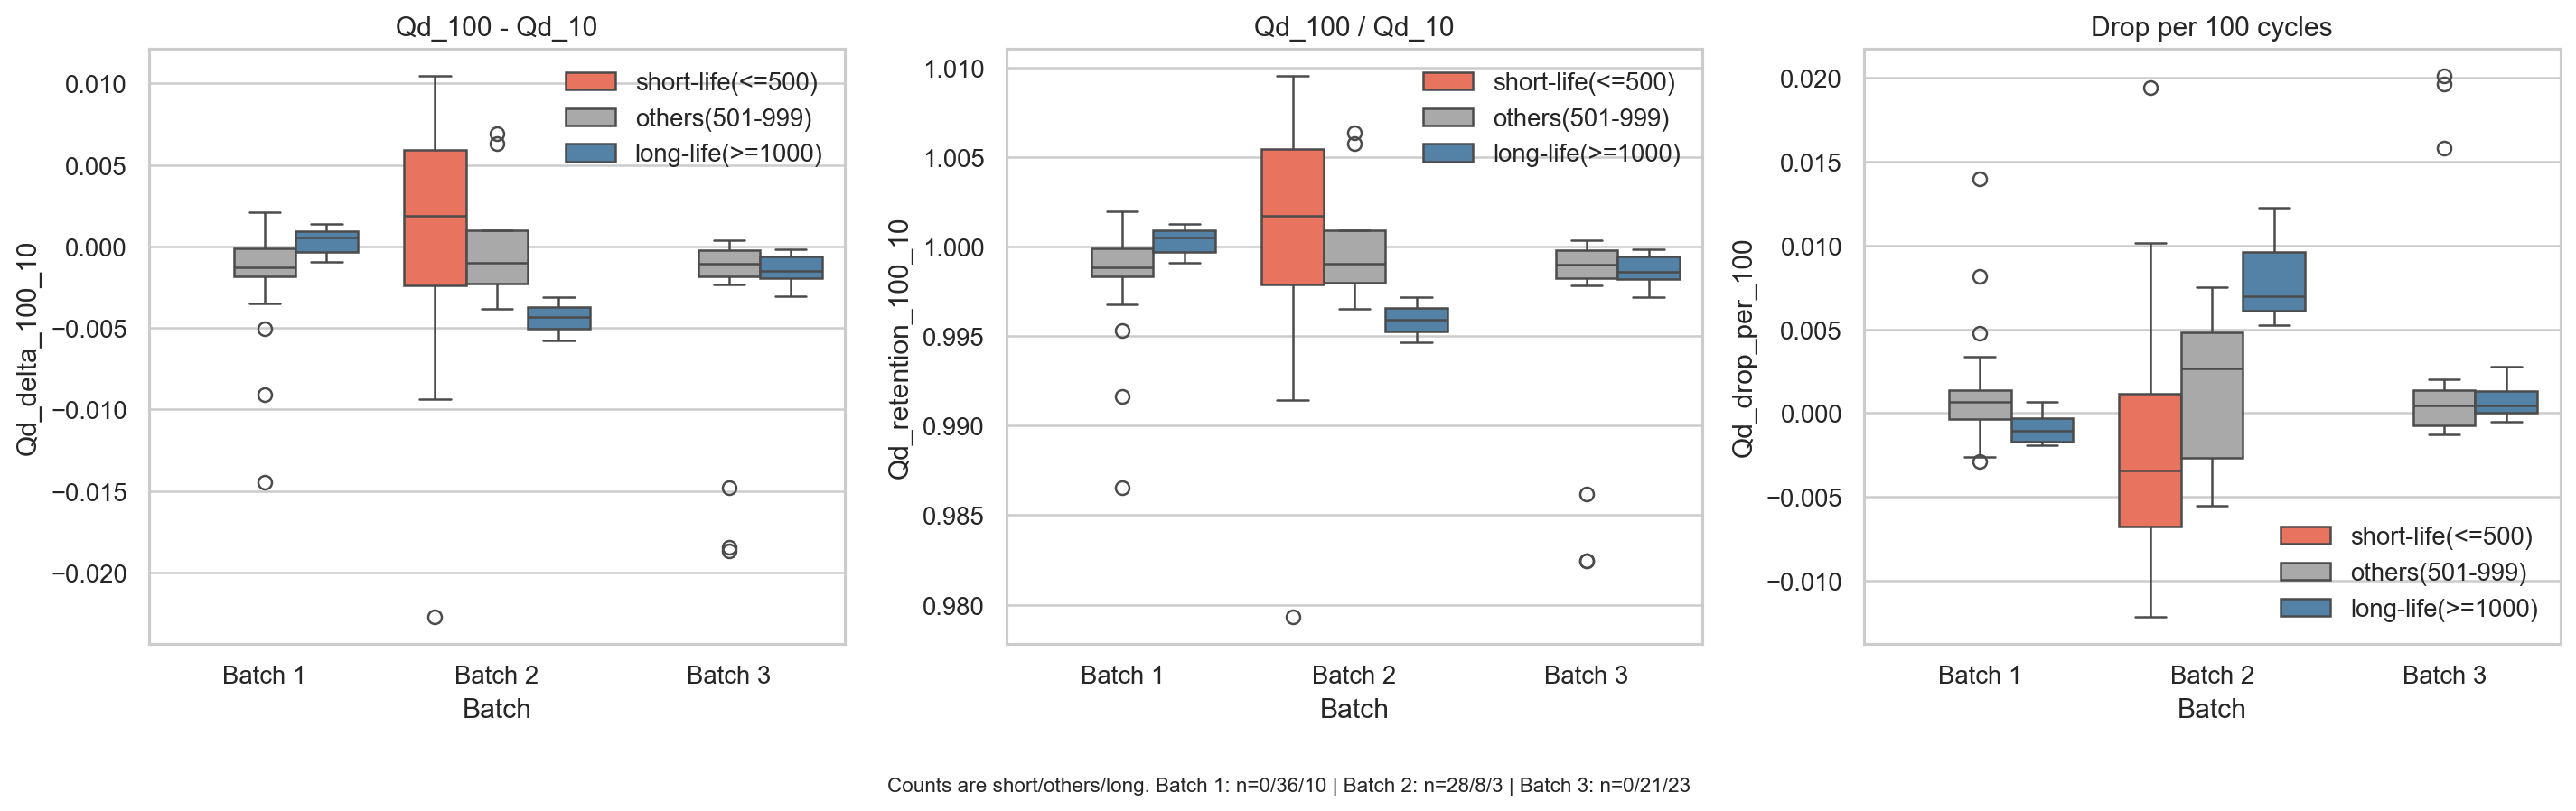

### Batch 1

,batch_key,batch_label,variant,feature,spearman_with_cycle_life
0,batch1,Batch 1,filtered,chargetime_100_mean,0.613050
1,batch1,Batch 1,filtered,Qd_delta_100_10,0.612619
2,batch1,Batch 1,filtered,Qd_retention_100_10,0.608055
3,batch1,Batch 1,filtered,Qd_slope_1_100,0.580486
4,batch1,Batch 1,filtered,Qd_100,0.324288
5,batch1,Batch 1,filtered,IR_100_mean,0.135500
6,batch1,Batch 1,filtered,Qd_10,0.100407
7,batch1,Batch 1,filtered,Tavg_100_mean,-0.371469
8,batch1,Batch 1,filtered,Qd_drop_per_100,-0.580486


### Batch 2

,batch_key,batch_label,variant,feature,spearman_with_cycle_life
0,batch2,Batch 2,filtered,Qd_drop_per_100,0.263994
1,batch2,Batch 2,filtered,Tavg_100_mean,0.176030
2,batch2,Batch 2,filtered,Qd_10,0.077336
3,batch2,Batch 2,filtered,Qd_100,0.077235
4,batch2,Batch 2,filtered,Qd_retention_100_10,-0.053244
5,batch2,Batch 2,filtered,Qd_delta_100_10,-0.054560
6,batch2,Batch 2,filtered,Qd_slope_1_100,-0.263994
7,batch2,Batch 2,filtered,IR_100_mean,-0.345638
8,batch2,Batch 2,filtered,chargetime_100_mean,-0.386780


### Batch 3

,batch_key,batch_label,variant,feature,spearman_with_cycle_life
0,batch3,Batch 3,filtered,chargetime_100_mean,0.196420
1,batch3,Batch 3,filtered,Qd_100,0.177532
2,batch3,Batch 3,filtered,IR_100_mean,0.168652
3,batch3,Batch 3,filtered,Qd_10,0.129960
4,batch3,Batch 3,filtered,Qd_slope_1_100,0.052717
5,batch3,Batch 3,filtered,Qd_delta_100_10,0.031503
6,batch3,Batch 3,filtered,Qd_retention_100_10,0.029530
7,batch3,Batch 3,filtered,Tavg_100_mean,0.025372
8,batch3,Batch 3,filtered,Qd_drop_per_100,-0.052717


In [9]:
display(Image(filename=str(analysis["figure_paths"]["feature_comparison"])))
for batch_label, sub in analysis["feature_correlations"].sort_values(
    ["batch_label", "spearman_with_cycle_life"], ascending=[True, False]
).groupby("batch_label"):
    display(Markdown(f"### {batch_label}"))
    display(sub.reset_index(drop=True))

## 9. Q2 해석의 안정성: raw와 filtered를 같이 봐도 결론이 유지되는가?

배치별 이상치 제거 비율과,
핵심 feature의 raw/filtered Spearman 차이를 비교한다.

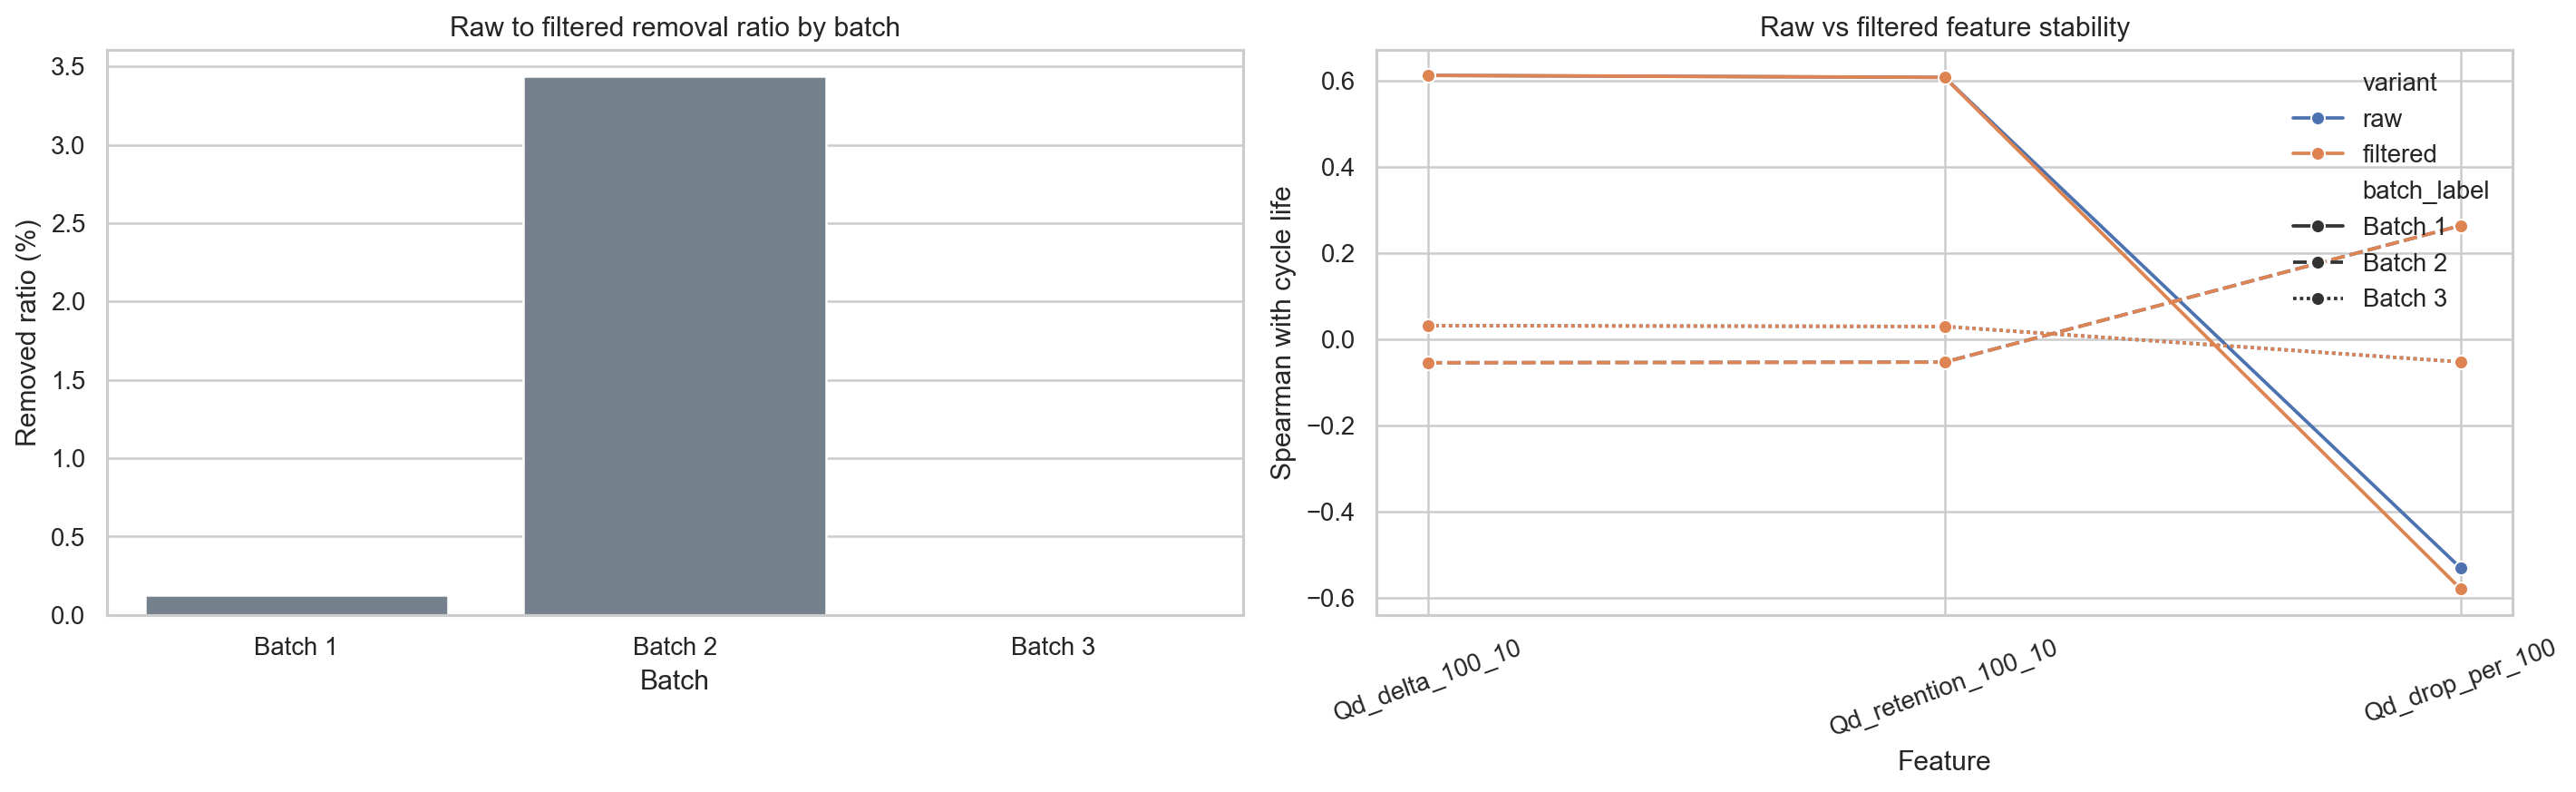

### Batch 1

,batch_key,batch_label,variant,feature,spearman_with_cycle_life
0,batch1,Batch 1,raw,Qd_delta_100_10,0.612619
1,batch1,Batch 1,raw,Qd_retention_100_10,0.608055
2,batch1,Batch 1,raw,Qd_drop_per_100,-0.532009
3,batch1,Batch 1,filtered,Qd_delta_100_10,0.612619
4,batch1,Batch 1,filtered,Qd_retention_100_10,0.608055
5,batch1,Batch 1,filtered,Qd_drop_per_100,-0.580486


### Batch 2

,batch_key,batch_label,variant,feature,spearman_with_cycle_life
0,batch2,Batch 2,raw,Qd_delta_100_10,-0.054560
1,batch2,Batch 2,raw,Qd_retention_100_10,-0.053244
2,batch2,Batch 2,raw,Qd_drop_per_100,0.263994
3,batch2,Batch 2,filtered,Qd_delta_100_10,-0.054560
4,batch2,Batch 2,filtered,Qd_retention_100_10,-0.053244
5,batch2,Batch 2,filtered,Qd_drop_per_100,0.263994


### Batch 3

,batch_key,batch_label,variant,feature,spearman_with_cycle_life
0,batch3,Batch 3,raw,Qd_delta_100_10,0.031503
1,batch3,Batch 3,raw,Qd_retention_100_10,0.029530
2,batch3,Batch 3,raw,Qd_drop_per_100,-0.052717
3,batch3,Batch 3,filtered,Qd_delta_100_10,0.031503
4,batch3,Batch 3,filtered,Qd_retention_100_10,0.029530
5,batch3,Batch 3,filtered,Qd_drop_per_100,-0.052717


In [10]:
display(Image(filename=str(analysis["figure_paths"]["raw_vs_filtered_sensitivity"])))
for batch_label, sub in analysis["raw_vs_filtered_correlations"][
    analysis["raw_vs_filtered_correlations"]["feature"].isin(
        ["Qd_delta_100_10", "Qd_retention_100_10", "Qd_drop_per_100"]
    )
].groupby("batch_label"):
    display(Markdown(f"### {batch_label}"))
    display(sub.reset_index(drop=True))

## 10. Q2 insight를 토대로 한 모델 설계 전략

세 배치의 공통 패턴과 배치 간 차이를 반영해,
검증 전략과 feature 설계 방향을 정리한다.

In [11]:
display(analysis["model_strategy"])
print(f"all.md saved to: {analysis['markdown_path']}")

,design_axis,recommendation,rationale
0,validation,Use batch-aware validation such as leave-one-b...,"Batch-level distribution shifts are visible, s..."
1,target signal,Keep both absolute Qd features and retention-s...,Within-batch life separation appears in early ...
2,core features,"Start with Qd_10, Qd_100, Qd_delta_100_10, Qd_...","These features summarize early degradation, im..."
3,batch context,Include batch or protocol metadata as explicit...,Charging policy and baseline life distribution...
4,robustness,Track performance under both raw and filtered ...,Outlier filtering barely changes the main dire...


all.md saved to: /Users/hyun/workspace/data/all.md
